In [1]:
################################### Notebook Details ####################################
#
# In this Notebook:
#   - we apply a slow-moving stochastic modulating signal only to a single node (other nodes are passively driven) 
#   - coupling coefficients are homogenous and manually set
#   - coupling are excitatory (i.e., additive coupling)

In [2]:
import os
import json
import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import special
from scipy.stats import norm
from scipy.stats import pearsonr
from scipy import signal
from scipy.fft import fftshift

from itertools import combinations, groupby
import networkx as nx

%matplotlib inline
plt.style.use('seaborn-bright')

C:\Users\kgaya\AppData\Local\Temp\ipykernel_27184\3960539547.py:20: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-bright')


In [3]:
# Setting paths
results_dir = "./SVLargeScaleNetwork_v2_outputs"
os.makedirs(results_dir, exist_ok = True)

sub_dir = sorted(os.listdir(results_dir))
if len(sub_dir) == 0:
    exp_no = 1
else:
    exp_no = int(sub_dir[-1].split('_')[-1]) + 1

results_dir = os.path.join(results_dir, f'exp_{exp_no:03d}')
print(f"Creating {results_dir}")
os.makedirs(results_dir, exist_ok = True)

write_json = {}

Creating ./SVLargeScaleNetwork_v2_outputs\exp_009


In [4]:
# (1) Connectivity and Inputs

write_json['T'] = T = 10000           # Time scale (au)
write_json['dt'] = dt = 0.1            # Integration time step
write_json['N'] = N = 10              # Network size
pop_size = 1000     # Subpopulation size

gamma = 0.016       # Conversion parameter to mV
wee = 1.6 / gamma   # E -> E subpopulation synaptic weight  
wei = 3 / gamma     # I -> E subpopulation synaptic weight
wie = -4.7 / gamma  # E -> I subpopulation synaptic weight
wii = -0.13 / gamma # I -> I subpopulation synaptic weight
tau_e = 1           # Time scale for E subpopulation
tau_i = 1 / 2       # Time scale for I subpopulation

beta = 300 * gamma  # slope of firing function

e_bias = -0.25 / gamma  # Bias for E subpopulation
i_bias = -0.5 / gamma   # Bias for I subpopulation

write_json['D0'] = D = 0.000 / (gamma ** 2)
time_arr = np.arange(0, T)

In [5]:
def gnp_random_connected_graph(n, p):
    """
    Generates a random undirected graph, similarly to an Erdős-Rényi 
    graph, but enforcing that the resulting graph is connected.
    """
    edges = combinations(range(n), 2)
    G = nx.Graph()
    G.add_nodes_from(range(n))
    if p <= 0:
        return G
    if p >= 1:
        return nx.complete_graph(n, create_using=G)
    for _, node_edges in groupby(edges, key=lambda x: x[0]):
        node_edges = list(node_edges)
        random_edge = random.choice(node_edges)
        G.add_edge(*random_edge)
        for e in node_edges:
            if random.random() < p:
                G.add_edge(*e)
    return G, nx.to_numpy_array(G)

Adjacency Matrix:
 [[0. 1. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 1. 1. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 1. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 1. 0. 1. 1. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]


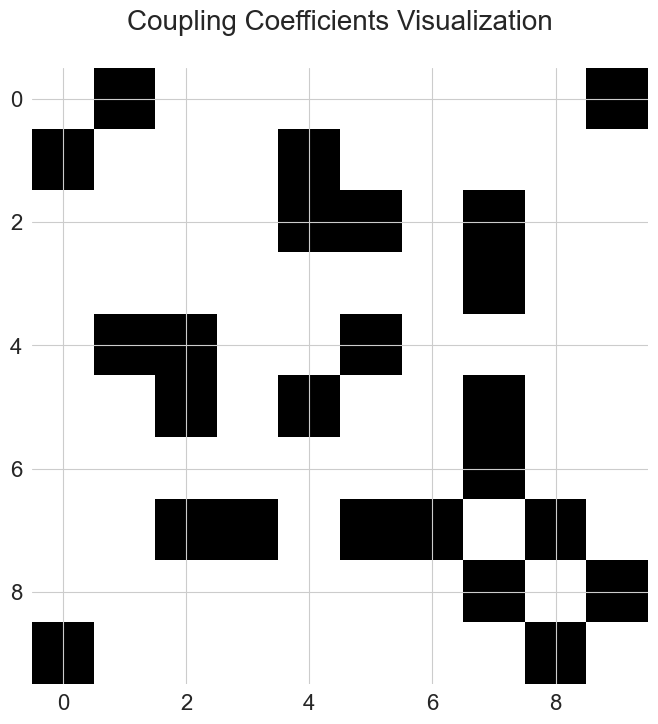

In [6]:
# Defining the Meso-Scale Network - Random Network (No Structure is assumed in the network)

write_json['rho'] = rho = 0.05          # Connectivity prob
prop = 0.8          # subpopulation proportion


# Setting the coupling coefficients
coupling_val = np.array([0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1, 2])
write_json['K_arr'] = list(coupling_val)

# Creaing the Random Network 
G, A = gnp_random_connected_graph(N, rho)

print("Adjacency Matrix:\n", A)
plt.figure(figsize=(8, 8))
plt.rcParams.update({'font.size': 16})
plt.imshow(A, cmap='bone_r', vmin=0, vmax=1)
for pos in ['right', 'top', 'bottom', 'left']:
    plt.gca().spines[pos].set_visible(False)
plt.title('Coupling Coefficients Visualization\n', fontsize=20)
plt.show()

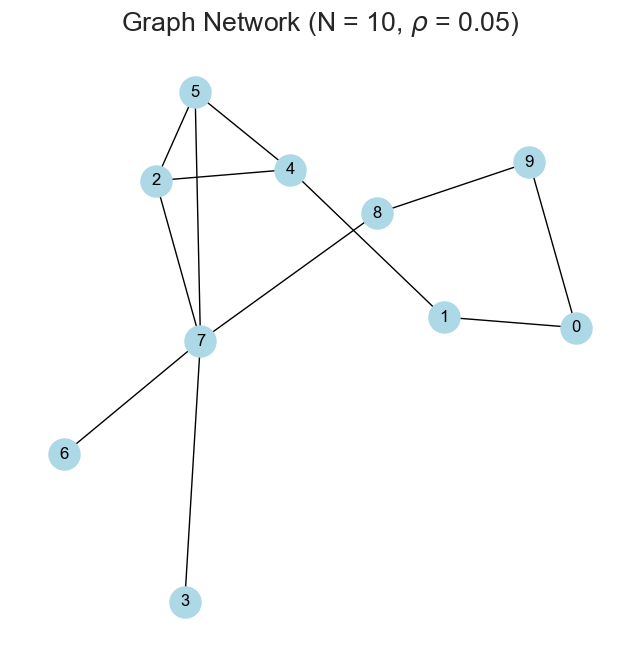

In [7]:
# Graph representation

plt.figure(figsize=(8, 8))
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)

nx.draw(G, node_color='lightblue', with_labels=True, node_size=500)
plt.title(f"Graph Network (N = {N}, " + r"$\rho$ = " + f"{rho:.2f})")
plt.show()


In [8]:
# Environmental perturbations - Slow-Moving Modulating Signal

write_json['N0'] = Noise = 0.05    # TODO: Change this is have low and high amplitude modulating signals

perturbations_1 = np.zeros(T)
filtered_noise_1 = np.zeros(T)
filtered_noise_2 = np.zeros(T)
filtered_noise_3 = np.zeros(T)

write_json['Dt'] = temp_scale = 0.1

for t in range(T - 1):
  perturbations_1[t + 1] = perturbations_1[t] + dt * (-perturbations_1[t] + filtered_noise_1[t])
  filtered_noise_1[t + 1] = filtered_noise_1[t] + dt  * temp_scale * (-filtered_noise_1[t] + filtered_noise_2[t])
  filtered_noise_2[t + 1] = filtered_noise_2[t] + dt  * temp_scale * (-filtered_noise_2[t] + filtered_noise_3[t])
  filtered_noise_3[t + 1] = filtered_noise_3[t] + dt * -filtered_noise_3[t] \
                            + np.sqrt(2 * Noise * dt) * np.random.normal(0, 1)

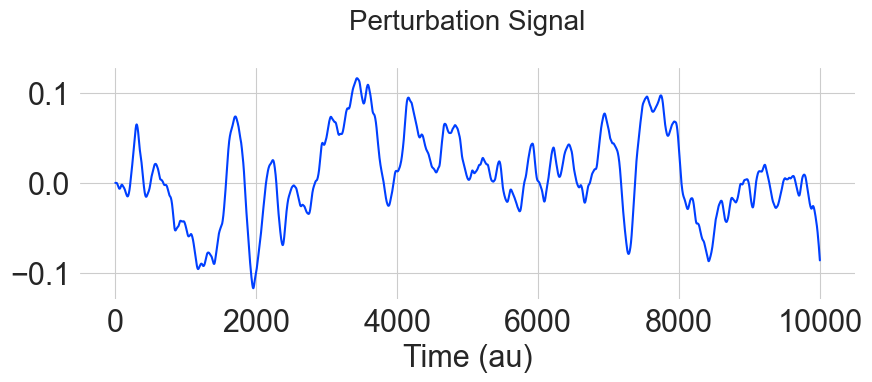

In [9]:
plt.figure(figsize=(10,3))
plt.rcParams.update({'font.size': 22})

plt.plot(time_arr, perturbations_1)
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.title('Perturbation Signal\n', fontsize=20)
plt.xlabel('Time (au)')
plt.show()

In [10]:
# Heterogeneity parameters (sigma_e, sigma_i) for nodes

# (1) Normal distribution
write_json['gauss_mu_e'] = mu_e = 7.0; write_json['gauss_sig_e'] = sig_e = 2.0
write_json['gauss_mu_i'] = mu_i = 10; write_json['gauss_sig_i'] = sig_i = 2.0

sigma_e_gaus = np.zeros(N)
sigma_i_gaus = np.zeros(N)

# (2) Gamma distribution (k.theta = mu, k.theta^2 = var)
write_json['gamma_K_e'] = k_e = 2.5; write_json['gamma_theta_e'] = theta_e = 1.5
write_json['gamma_K_i'] = k_i = 4.0; write_json['gamma_theta_i'] = theta_i = 2

sigma_e_gamma = np.zeros(N)
sigma_i_gamma = np.zeros(N)

for i in range(N):
    sigma_e_gaus[i] = np.random.normal(mu_e, sig_e, 1)
    sigma_e_gamma[i] = np.random.gamma(k_e, theta_e, 1)
    
for i in range(N):
    sigma_i_gaus[i] = np.random.normal(mu_i, sig_i, 1)
    sigma_i_gamma[i] = np.random.gamma(k_i, theta_i, 1)

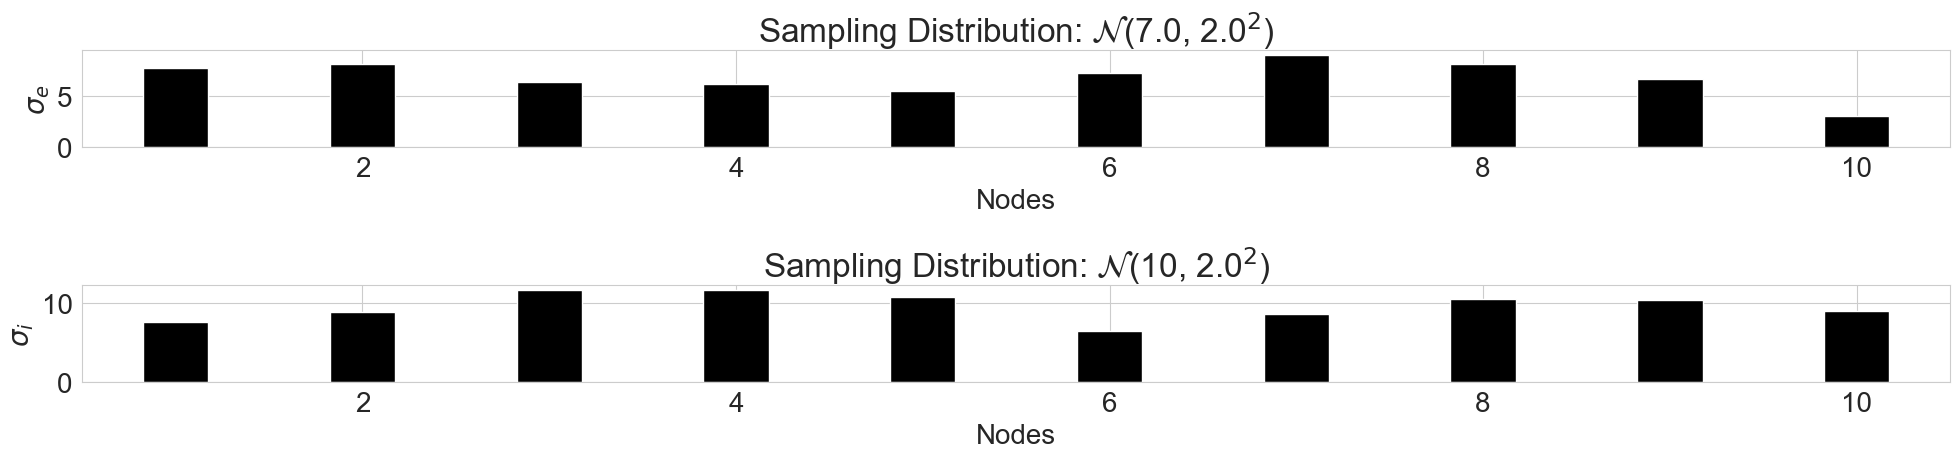

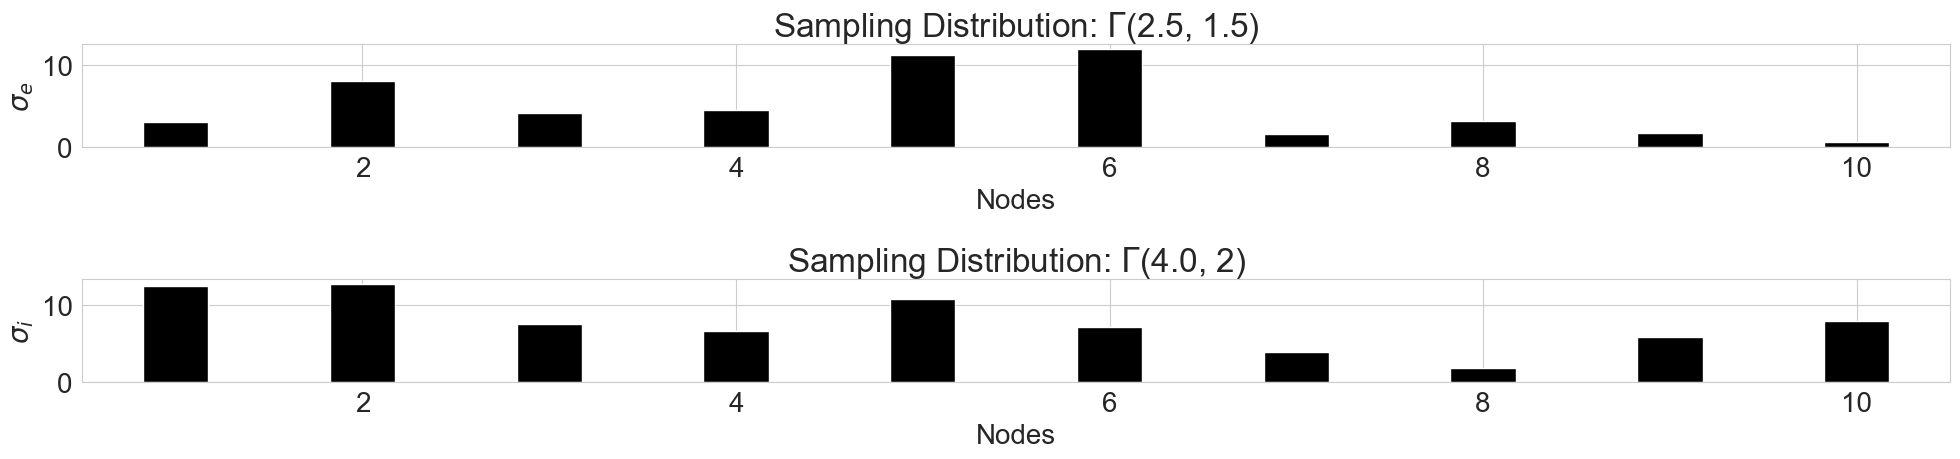

In [11]:
fig_path = os.path.join(results_dir, f"N_{N}_sigma_dist.png")

x = np.arange(N) + 1

# Width of the bars
width = 0.35

plt.figure(figsize=(20, 5))
plt.rcParams.update({'font.size': 20})
plt.subplot(2, 1, 1)
plt.bar(x, sigma_e_gaus, width, color = 'k')
plt.xlim([0.5, N + 0.5])
plt.ylabel(r'$\sigma_e$'); plt.xlabel('Nodes')
plt.title(r'Sampling Distribution: $\mathcal{N}$' + f'({mu_e}, {sig_e}' + r'$^2$)')

plt.subplot(2, 1, 2)
plt.bar(x, sigma_i_gaus, width, color = 'k')
plt.xlim([0.5, N + 0.5])
plt.ylabel(r'$\sigma_i$'); plt.xlabel('Nodes')
plt.title(r'Sampling Distribution: $\mathcal{N}$' + f'({mu_i}, {sig_i}' + r'$^2$)')

plt.tight_layout()
plt.savefig(os.path.join(results_dir, f'N_{N}_Gaussian_sigma_dist.png'), dpi = 600)
plt.show()

plt.figure(figsize=(20, 5))
plt.rcParams.update({'font.size': 20})
plt.subplot(2, 1, 1)
plt.bar(x, sigma_e_gamma, width, color = 'k')
plt.xlim([0.5, N + 0.5])
plt.ylabel(r'$\sigma_e$'); plt.xlabel('Nodes')
plt.title(r'Sampling Distribution: $\Gamma$' + f'({k_e}, {theta_e})')

plt.subplot(2, 1, 2)
plt.bar(x, sigma_i_gamma, width, color = 'k')
plt.xlim([0.5, N + 0.5])
plt.ylabel(r'$\sigma_i$'); plt.xlabel('Nodes')
plt.title(r'Sampling Distribution: $\Gamma$' + f'({k_i}, {theta_i})')

plt.tight_layout()
plt.savefig(os.path.join(results_dir, f'N_{N}_Gamma_sigma_dist.png'), dpi = 600)
plt.show()

C:\Users\kgaya\AppData\Local\Temp\ipykernel_27184\3789575185.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sigma_e_gaus, kde=True, bins=20, hist=False)
C:\Users\kgaya\AppData\Local\Temp\ipykernel_27184\3789575185.py:16: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sigma_

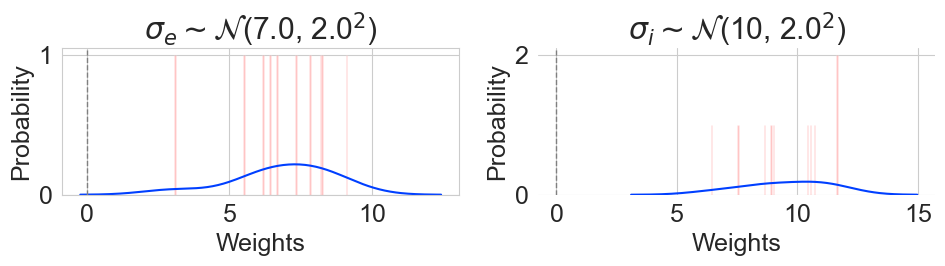

C:\Users\kgaya\AppData\Local\Temp\ipykernel_27184\3789575185.py:35: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sigma_e_gamma, kde=True, bins=20, hist=False)
C:\Users\kgaya\AppData\Local\Temp\ipykernel_27184\3789575185.py:46: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sigm

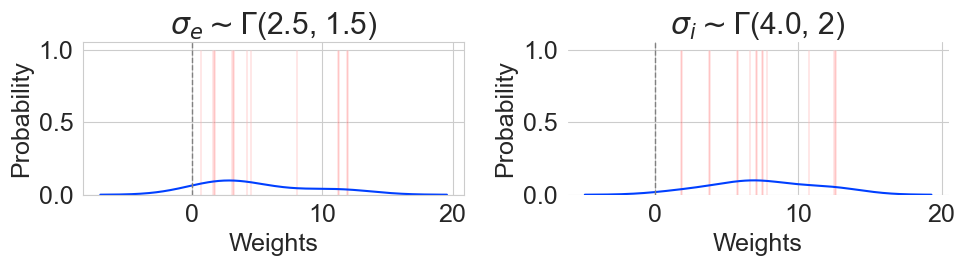

In [12]:
plt.figure(figsize=(10, 3))
plt.rcParams.update({'font.size': 18})

plt.subplot(1, 2, 1)
sns.distplot(sigma_e_gaus, kde=True, bins=20, hist=False)
_, _, bars = plt.hist(sigma_e_gaus, bins = 100, color="blue",alpha=0.25)
for bar in bars:
    if bar.get_x() > 0:
        bar.set_facecolor("red")
plt.axvline(x=0, linestyle='--',linewidth=1, color='grey')
plt.xlabel('Weights')
plt.ylabel('Probability')
plt.title(r"$\sigma_e \sim \mathcal{N}$" + f"({mu_e}, {sig_e}" + r"$^2$)")

plt.subplot(1, 2, 2)
sns.distplot(sigma_i_gaus, kde=True, bins=20, hist=False)
_, _, bars = plt.hist(sigma_i_gaus, bins = 100, color="blue",alpha=0.25)
for bar in bars:
    if bar.get_x() > 0:
        bar.set_facecolor("red")
plt.axvline(x=0, linestyle='--',linewidth=1, color='grey')
plt.xlabel('Weights')
plt.ylabel('Probability')
plt.title(r"$\sigma_i \sim \mathcal{N}$" + f"({mu_i}, {sig_i}" + r"$^2$)")

for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3))
plt.rcParams.update({'font.size': 18})

plt.subplot(1, 2, 1)
sns.distplot(sigma_e_gamma, kde=True, bins=20, hist=False)
_, _, bars = plt.hist(sigma_e_gamma, bins = 100, color="blue",alpha=0.25)
for bar in bars:
    if bar.get_x() > 0:
        bar.set_facecolor("red")
plt.axvline(x=0, linestyle='--',linewidth=1, color='grey')
plt.xlabel('Weights')
plt.ylabel('Probability')
plt.title(r"$\sigma_e \sim \Gamma$" + f"({k_e}, {theta_e})")

plt.subplot(1, 2, 2)
sns.distplot(sigma_i_gamma, kde=True, bins=20, hist=False)
_, _, bars = plt.hist(sigma_i_gamma, bins = 100, color="blue",alpha=0.25)
for bar in bars:
    if bar.get_x() > 0:
        bar.set_facecolor("red")
plt.axvline(x=0, linestyle='--',linewidth=1, color='grey')
plt.xlabel('Weights')
plt.ylabel('Probability')
plt.title(r"$\sigma_i \sim \Gamma$" + f"({k_i}, {theta_i})")

for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.tight_layout()
plt.show()

In [13]:
# resonse function of neurons
def f(x, beta, thresh):
    return 1 / (1 + np.exp(-beta * (x - thresh)))

def F(x, beta, thresh, gamma, sig):
    vmin = -1 / gamma; vmax = 1 / gamma; nsteps = 1000
    dv = np.abs(vmax - vmin) / nsteps
    v = np.arange(vmin, vmax, dv)

    if type(x) == np.ndarray and len(x.shape) == 4:
        x = np.repeat(x[:, :, :, :, np.newaxis], nsteps, axis=4)
    sigmoid_vals = f(x + v, beta, thresh)
    normal_vals = np.exp(-v ** 2 / (2 * sig ** 2)) / np.sqrt(2 * np.pi * sig ** 2)

    return np.sum(dv * sigmoid_vals * normal_vals, axis=-1)

In [106]:
def plot_temp_lypunov(u_e, u_i, coupling, path = results_dir, fig_name = "", size = (40, 20)):
    plt.figure(figsize = size)
    plt.rcParams.update({'font.size': 30})
    
    n_nodes, _ = u_e.shape
    
    plt.subplot(3, 1, 1)
    plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, n_nodes))))
    
    for i in range(n_nodes):
        plt.plot(time_arr, u_e[i][:], label = f'Node {i+1:01d}')

    plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
    plt.plot(time_arr, perturbations_1 / gamma, color='red',  linewidth=4, alpha=0.5, label = 'S(t)')
    
    for pos in ['right', 'top', 'bottom', 'left']:
       plt.gca().spines[pos].set_visible(False)
    
    plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
    plt.xlim(0, T); plt.ylabel(r"$U_e^k$")
    plt.title(f"Time series for N = {N} with " + r"$\rho$ = " + f"{rho} and K = {coupling}")
    
    plt.subplot(3, 1, 2)
    plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, n_nodes))))
    
    for i in range(n_nodes):
        plt.plot(time_arr, u_i[i][:], label = f'Node {i+1:01d}')

    plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
    plt.plot(time_arr, perturbations_1 / gamma, color='red',  linewidth=4, alpha=0.5, label = 'S(t)')
    
    for pos in ['right', 'top', 'bottom', 'left']:
       plt.gca().spines[pos].set_visible(False)
    
    plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
    plt.xlim(0, T); plt.ylabel(r"$U_i^k$")
    plt.title(f"Time series for N = {N} with " + r"$\rho$ = " + f"{rho} and K = {coupling}")
    
    T1 = 200
    t_prime = time_arr[T1: T - 1]
    plt.subplot(3, 1, 3)
    plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, n_nodes))))
    
    for i in range(n_nodes):
      plt.plot(t_prime, np.log(np.abs(np.diff(u_e[i][T1 : T])/0.1)), label = f'Node {i+1:01d}')
        
    plt.plot(t_prime,np.zeros(T - 1 - T1),"--", color='red')
    for pos in ['right', 'top', 'bottom', 'left']:
       plt.gca().spines[pos].set_visible(False)
    plt.tick_params(axis='y', which='both', labelleft=False, labelright=True) 
    plt.xlim(0, T); plt.ylabel(r"$\lambda_e$")
    
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.45), fontsize=20, ncols=5, fancybox=True, shadow=True)
    plt.title(f"Lyapunov series for N = {N} with " + r"$\rho$ = " + f"{rho} and K = {coupling}")
    
    plt.tight_layout()
    plt.savefig(os.path.join(path, fig_name + '.png'), dpi = 600)
    plt.show()
    return 

In [15]:
# Dumping parameter dictionary to result directory
with open(os.path.join(results_dir, 'parameters.json'), 'w+') as output_file:
    json.dump(write_json, output_file, indent = 3)

Running Simulation for K = 0.3
Initialization...
Simulation Start --> 

C:\Users\kgaya\AppData\Local\Temp\ipykernel_27184\3118493370.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * (x - thresh)))


Simulation End! Time taken = 14.119s


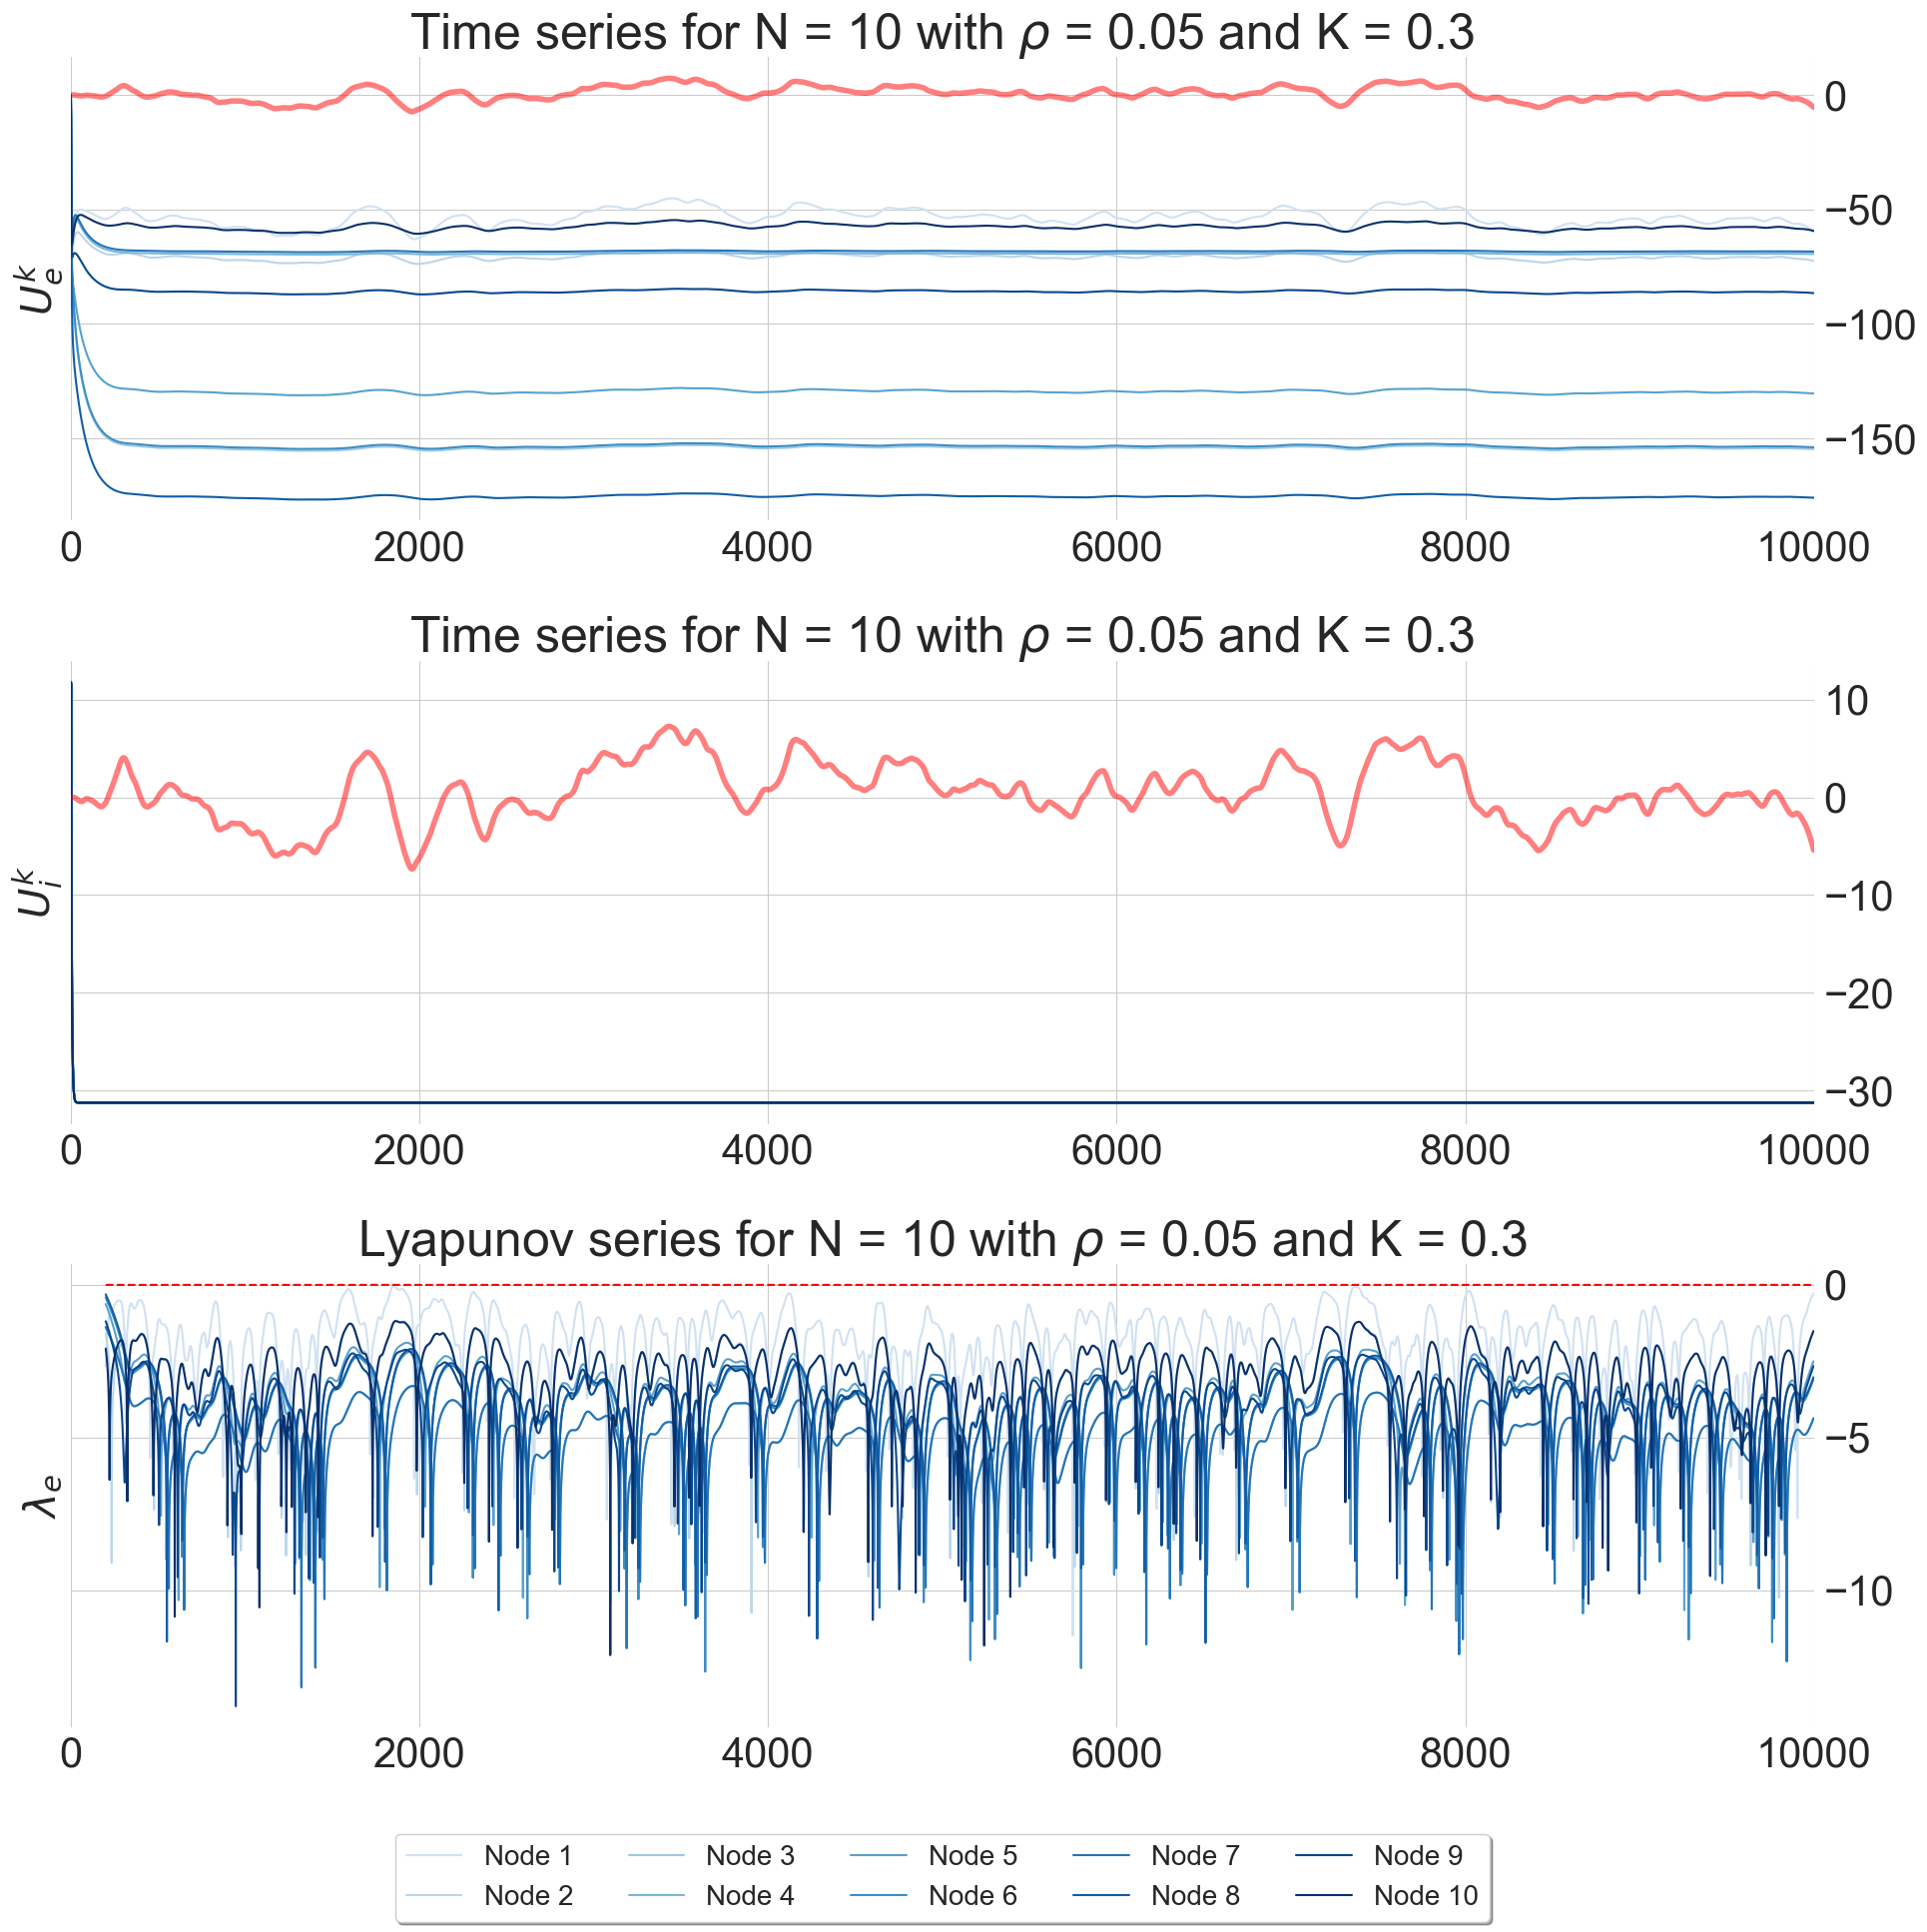

Saving Excitatory Data!
Saving Inhibitory Data!


In [114]:
# (2) Network Dynamics (Loop through the coupling weights)

sample_dist = 'gaussian'
sigma_e_gaus[6] = sigma_i_gaus[6]
if sample_dist == 'gaussian':
    sigma_e = sigma_e_gaus
    sigma_i = sigma_i_gaus
elif sample_dist == 'gamma':
    sigma_e = sigma_e_gamma
    sigma_i = sigma_i_gamma
else:
    raise Exception(f'{sample_dist} distribution not implemented!')

os.makedirs(os.path.join(results_dir, sample_dist), exist_ok = True)

for l, K in enumerate(coupling_val[5:6]):
    ue = np.zeros((N, T))
    ui = np.zeros((N, T))
    
    W = K * A
    
    print(f'Running Simulation for K = {K}')
    # TODO: Can we have heterogeneity in mean firing thresh for each population?
    thresh_e_sig = 0.0      # mean firing threshold for E-subpopulation
    thresh_i_sig = 0.0      # mean firing threshold for I-subpopulation
    
    thresh_e = np.zeros(N)
    thresh_i = np.zeros(N)

    # Initialization
    print("Initialization...")
    for i in range(N):
      ue[i][0] = 0.05 * np.random.normal(0, 1)
      ui[i][0] = 0.05 * np.random.normal(0, 1)
      
      thresh_e[i] = np.sqrt(thresh_e_sig) * np.random.normal(0,1)
      thresh_i[i] = np.sqrt(thresh_i_sig) * np.random.normal(0,1)
    
    # Euler Integration
    print("Simulation Start --> ", end = '')
    tic = time.time()
    for t in range(T - 1):
      for i in range(N):
        _sum_i = 0
        _sum_e = np.matmul(W[i, :], ue[:, t])
        
        if i == 0:
            _sum_e += perturbations_1[t] / gamma
        
        _sum_e += wee * F(ue[i][t], beta, thresh_e[i], gamma, sigma_e[i]) 
        _sum_e += wie * F(ui[i][t], beta, thresh_i[i], gamma, sigma_i[i])
        ue[i][t + 1] = ue[i][t] + dt / tau_e * (-ue[i][t] + _sum_e + e_bias) \
                       + np.sqrt(2 * D * dt / tau_e) * np.random.normal(0, 1)
        
        _sum_i += wei * F(ue[i][t], beta, thresh_e[i], gamma, sigma_e[i]) 
        _sum_i += wii * F(ui[i][t], beta, thresh_i[i], gamma, sigma_i[i])
        ui[i][t + 1] = ui[i][t] + dt / tau_i * (-ui[i][t] + _sum_i + i_bias) \
                       + np.sqrt(2 * D * dt / tau_i) * np.random.normal(0, 1)
    toc = time.time()
    print(f"Simulation End! Time taken = {toc - tic :.3f}s")
    save_fig = f"N_{N}_rho_{rho:.2f}_coupling_{K:.2f}"
    plot_temp_lypunov(ue, ui, K, path = os.path.join(results_dir, sample_dist), fig_name = save_fig, size = (20, 20))
    
    df = pd.DataFrame(ue.T, columns = [f'Node {i + 1:03d}' for i in range(N) ])
    df.to_csv(os.path.join(results_dir, sample_dist, f'ue_N_{N}_rho_{rho:.2f}_coupling_{K:.2f}.csv'), sep = '\t')
    print('Saving Excitatory Data!')
    
    df = pd.DataFrame(ui.T, columns = [f'Node {i + 1:03d}' for i in range(N) ])
    df.to_csv(os.path.join(results_dir, sample_dist, f'ui_N_{N}_rho_{rho:.2f}_coupling_{K:.2f}.csv'), sep = '\t')
    print('Saving Inhibitory Data!')
    
    del df

In [117]:
pos_lyap_ind = []
for i in range(N):
    lyap_val = np.max(np.log(np.abs(np.diff(ue[i][200 : T])/0.1)))
    print(f"Node {i + 1:03d} :: max_lyapunov = {lyap_val:.2f} | sigma_e = {sigma_e[i]:.2f} | sigma_i = {sigma_i[i]:.2f}")
    if lyap_val > 1e-5:
        pos_lyap_ind.append(i)

Node 001 :: max_lyapunov = -0.04 | sigma_e = 7.84 | sigma_i = 7.54
Node 002 :: max_lyapunov = -1.17 | sigma_e = 8.24 | sigma_i = 8.91
Node 003 :: max_lyapunov = -0.41 | sigma_e = 6.40 | sigma_i = 11.63
Node 004 :: max_lyapunov = -1.38 | sigma_e = 6.20 | sigma_i = 11.67
Node 005 :: max_lyapunov = -0.63 | sigma_e = 5.50 | sigma_i = 10.71
Node 006 :: max_lyapunov = -0.41 | sigma_e = 7.37 | sigma_i = 6.40
Node 007 :: max_lyapunov = -1.38 | sigma_e = 8.64 | sigma_i = 8.64
Node 008 :: max_lyapunov = -0.31 | sigma_e = 8.18 | sigma_i = 10.53
Node 009 :: max_lyapunov = -1.19 | sigma_e = 6.70 | sigma_i = 10.43
Node 010 :: max_lyapunov = -1.18 | sigma_e = 3.05 | sigma_i = 8.99


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


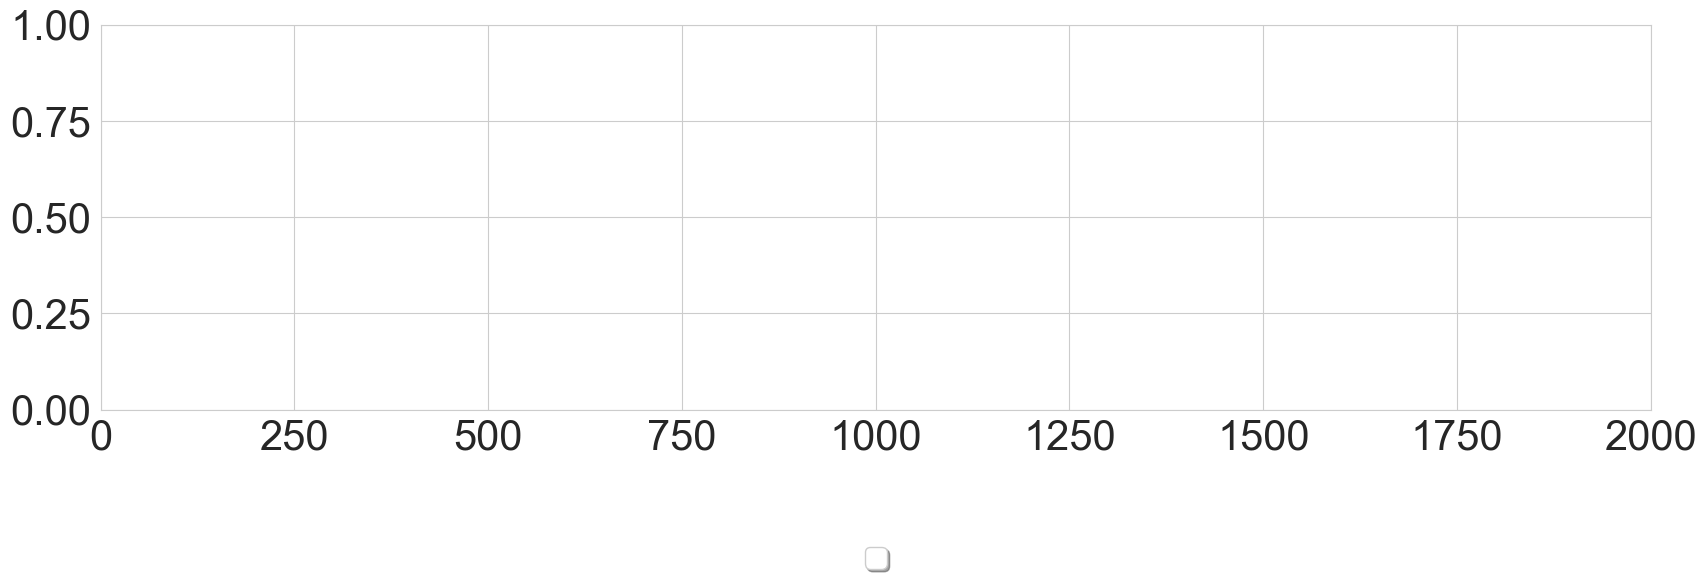

In [118]:
plt.figure(figsize = (20, 5))
plt.rcParams.update({'font.size': 30})

for k in pos_lyap_ind:
    plt.plot(time_arr[:T - 200], ue[k][200:], label = f'Node {k:03d}')

plt.tight_layout()
plt.xlim(0, 2000)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.45), fontsize=20, ncols=3, fancybox=True, shadow=True)

In [119]:
for k in pos_lyap_ind:
    plt.figure(figsize = (5, 5))
    plt.rcParams.update({'font.size': 18})

    plt.plot(ue[k][200:], ui[k][200:])
    plt.xlabel(r'$U_e$'); plt.ylabel(r'$U_i$')
    plt.title(f'Phase Plane - Node {k + 1:03d}')

In [120]:
# Variance Analysis
ue_analyse = ue[:, 200:]
ue_var = np.var(ue_analyse - np.mean(ue_analyse, axis=1, keepdims=True), axis=1)

Text(0.5, 1.0, 'Variance of Time Series (N = 10, K = 0.3)')

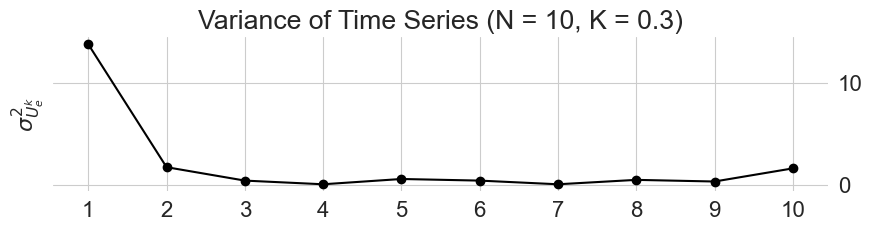

In [121]:
plt.figure(figsize = (10, 2))
plt.rcParams.update({'font.size': 16})

plt.plot(np.arange(1, 11, 1), ue_var, 'k-o')

plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)

plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
plt.xticks(np.arange(1, N + 1)); plt.ylabel(r"$\sigma^2_{U_e^k}$")
plt.title(f"Variance of Time Series (N = {N}, K = {K})")

In [ ]:
# Correlations between the Node Activities
from scipy.spatial import distance
import dcor

# (1) Pearson Cross-Correlation 
corr_matrix = np.zeros((N, N))

for l in range(N):
    data_1 = ue[l][200:]
    for k in range(N):
        if l == k:
            continue
        data_2 = ue[k][200:]
        corr_matrix[l][k] = pearsonr(data_1 - np.mean(data_1), data_2 - np.mean(data_2))[0]

plt.figure(figsize = (12, 10))
plt.pcolormesh(np.arange(0.5, 11, 1), np.arange(0.5, 11, 1), corr_matrix, cmap='hot', edgecolors = 'k')
plt.xticks(np.arange(1, 11, 1)); plt.yticks(np.arange(1, 11, 1))
plt.xlabel('Node #'); plt.ylabel('Node #')
plt.title(f'Pearson Cross-Correlation ' + r'($\rho$ = ' + f'{rho:.2f}, K = {K})\n')
plt.colorbar()
plt.show()

# (2) Distance Correlation
# Source:: https://www.wikiwand.com/en/Distance_correlation

dist_corr = np.zeros((N, N))

for l in range(N):
    data_1 = ue[l]
    for k in range(N):
        if l == k:
            continue
        data_2 = ue[k]
        
        dist_corr[l][k] = dcor.distance_correlation(data_1 - np.mean(data_1), data_2 - np.mean(data_2))
        print(f'corr({l}, {k}) = {dist_corr[l][k]}')
plt.figure(figsize = (12, 10))
plt.pcolormesh(np.arange(0.5, 11, 1), np.arange(0.5, 11, 1), dist_corr, cmap='hot', edgecolors = 'k')
plt.xticks(np.arange(1, 11, 1)); plt.yticks(np.arange(1, 11, 1))
plt.xlabel('Node #'); plt.ylabel('Node #')
plt.title(f'Pearson Cross-Correlation ' + r'($\rho$ = ' + f'{rho:.2f}, K = {K})\n')
plt.colorbar()
plt.show()

# (3) Maximal Information Coefficient (Based on Binning and Mutual Information)

# (4) Wavelet Coherence

In [ ]:
dist_corr

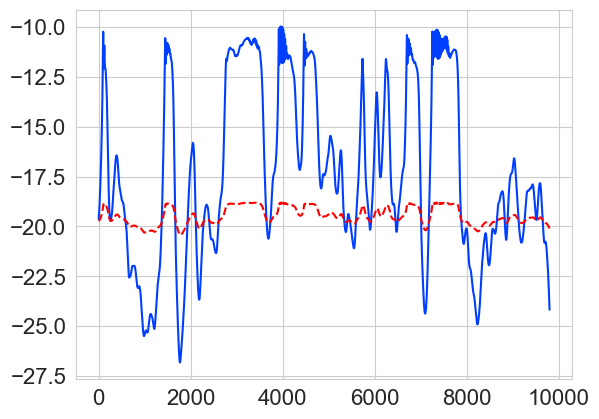

In [104]:
plt.plot(ue[0][200:])
plt.plot(ue[9][200:], 'r--')
# plt.xlim(0, 500)

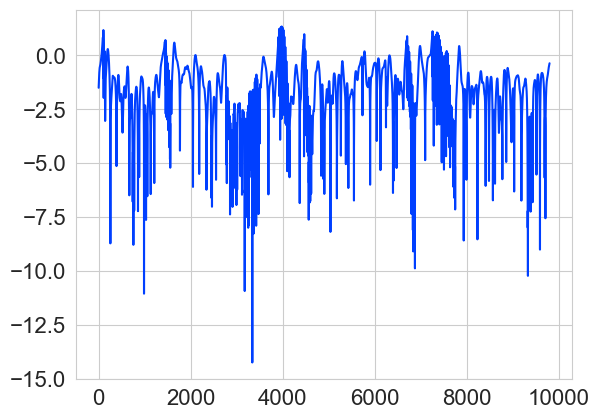

In [105]:
plt.plot(np.log(np.abs(np.diff(ue[0][200:])/0.1)))
# plt.xlim(0, 500)

In [ ]:
# Phase Coherence (using Hilbert Transform)
from scipy.signal import hilbert

hilb_signal = hilbert(ue[8][200:])

plt.figure(figsize = (10, 6))
plt.subplot(2, 1, 1)
plt.plot(time_arr[:-200], ue[8][200:])

plt.subplot(2, 1, 2)
plt.plot(np.angle(hilb_signal))

plt.tight_layout()

In [ ]:
hilb_signal = hilbert(ue[4][200:])

plt.figure(figsize = (10, 6))
plt.subplot(2, 1, 1)
plt.plot(time_arr[:-200], ue[4][200:])

plt.subplot(2, 1, 2)
plt.plot(np.angle(hilb_signal))

plt.tight_layout()

In [ ]:
s = np.sin(10 * np.linspace(0, 1, 1000))
v = np.cos(10 * np.linspace(0, 1, 1000))

dcor.distance_correlation(s, v)

In [ ]:
distcorr(s, v)

In [ ]:
dcor.distance_stats(ue[4][200:], ue[2][200:])

In [ ]:
v_hilbert = hilbert(v)

In [ ]:
plt.plot(np.abs(v))

In [ ]:
plt.plot(np.angle(v_hilbert))

In [ ]:
v_hilbert